# Week 2 - Data Exploration with pandas

This notebook performs basic EDA for the required modeling population:

- `PropertyType == "Residential"`
- `PropertySubType == "SingleFamilyResidence"`

The target variable is `ClosePrice`. The main exploratory variables are `LivingArea`, bedrooms, bathrooms, and lot size.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")

## Load selected columns

Only the columns needed for this EDA are loaded from each CSV. This keeps the notebook responsive while preserving the raw source files.

In [3]:
DATA_DIR = Path("data")
CSV_FILES = sorted(DATA_DIR.glob("CRMLSSold*.csv"))

CORE_COLUMNS = [
    "CloseDate",
    "ClosePrice",
    "PropertyType",
    "PropertySubType",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeArea",
    "LotSizeSquareFeet",
]

len(CSV_FILES), [p.name for p in CSV_FILES[:5]], [p.name for p in CSV_FILES[-5:]]

(30,
 ['CRMLSSold20220101_20231231_filled.csv',
  'CRMLSSold202401_filled.csv',
  'CRMLSSold202402_filled.csv',
  'CRMLSSold202403_filled.csv',
  'CRMLSSold202404_filled.csv'],
 ['CRMLSSold202601.csv',
  'CRMLSSold202602.csv',
  'CRMLSSold202603.csv',
  'CRMLSSold202604.csv',
  'CRMLSSold202605.csv'])

In [4]:
frames = []

for path in CSV_FILES:
    frame = pd.read_csv(
        path,
        usecols=lambda column: column in CORE_COLUMNS,
        low_memory=False,
    )
    frame["source_file"] = path.name
    frames.append(frame)

raw = pd.concat(frames, ignore_index=True)

raw.shape

(794271, 10)

## Restrict to the task population

In [5]:
property_type = raw["PropertyType"].astype("string").str.strip()
property_subtype = raw["PropertySubType"].astype("string").str.strip()

single_family = raw.loc[
    property_type.eq("Residential")
    & property_subtype.eq("SingleFamilyResidence")
].copy()

scope_summary = pd.DataFrame(
    {
        "rows": [len(raw), len(single_family)],
        "percent_of_raw": [100, len(single_family) / len(raw) * 100],
    },
    index=["raw_rows", "residential_single_family_rows"],
)

scope_summary

,rows,percent_of_raw
raw_rows,794271,100.00
residential_single_family_rows,399157,50.25


In [6]:
raw["PropertyType"].value_counts(dropna=False).head(10)

PropertyType
Residential            532920
ResidentialLease       181556
Land                    27429
ManufacturedInPark      21429
ResidentialIncome       21015
CommercialSale           5164
CommercialLease          4205
BusinessOpportunity       552
Resid                       1
Name: count, dtype: int64

In [7]:
raw.loc[property_type.eq("Residential"), "PropertySubType"].value_counts(dropna=False).head(15)

PropertySubType
SingleFamilyResidence    399157
Condominium               87907
Townhouse                 31037
ManufacturedOnLand         6892
Duplex                     2922
StockCooperative           2127
NaN                        1015
Cabin                       585
Triplex                     414
MixedUse                    258
Quadruplex                  173
BoatSlip                    109
OwnYourOwn                   89
MobileHome                   59
ManufacturedHome             44
Name: count, dtype: int64

## Clean numeric EDA fields

`LotSizeSquareFeet` is used as the primary lot-size field. If it is missing, the notebook falls back to `LotSizeArea` for a basic Week 2 view.

In [8]:
def to_number(series):
    return pd.to_numeric(
        series.astype("string").str.replace(r"[$,]", "", regex=True),
        errors="coerce",
    )


eda = pd.DataFrame(
    {
        "CloseDate": pd.to_datetime(single_family["CloseDate"], errors="coerce"),
        "ClosePrice": to_number(single_family["ClosePrice"]),
        "LivingArea": to_number(single_family["LivingArea"]),
        "Bedrooms": to_number(single_family["BedroomsTotal"]),
        "Bathrooms": to_number(single_family["BathroomsTotalInteger"]),
        "LotSize": to_number(single_family["LotSizeSquareFeet"]).combine_first(
            to_number(single_family["LotSizeArea"])
        ),
        "source_file": single_family["source_file"],
    }
)

eda.head()

,CloseDate,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize,source_file
3,2022-01-04,"2,499,999.00","2,645.00",4.00,4.00,"13,376.00",CRMLSSold20220101_20231231_filled.csv
6,2022-01-10,"640,000.00","2,070.00",3.00,3.00,"3,397.00",CRMLSSold20220101_20231231_filled.csv
7,2022-03-23,"438,000.00","1,174.00",3.00,2.00,"9,900.00",CRMLSSold20220101_20231231_filled.csv
12,2022-01-10,"615,000.00","1,996.00",2.00,2.00,"6,098.00",CRMLSSold20220101_20231231_filled.csv
14,2022-01-19,"399,990.00","1,422.00",3.00,2.00,"12,197.00",CRMLSSold20220101_20231231_filled.csv


In [9]:
eda.info()

<class 'pandas.DataFrame'>
Index: 399157 entries, 3 to 794267
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   CloseDate    399157 non-null  datetime64[us]
 1   ClosePrice   399155 non-null  Float64       
 2   LivingArea   398947 non-null  Float64       
 3   Bedrooms     399157 non-null  Float64       
 4   Bathrooms    399082 non-null  Float64       
 5   LotSize      392368 non-null  Float64       
 6   source_file  399157 non-null  str           
dtypes: Float64(5), datetime64[us](1), str(1)
memory usage: 26.3 MB


## Missingness and summary statistics

In [10]:
eda_fields = ["ClosePrice", "LivingArea", "Bedrooms", "Bathrooms", "LotSize"]

missingness = pd.DataFrame(
    {
        "missing_rows": eda[eda_fields].isna().sum(),
        "missing_percent": eda[eda_fields].isna().mean() * 100,
    }
).sort_values("missing_percent", ascending=False)

missingness

,missing_rows,missing_percent
LotSize,6789,1.70
LivingArea,210,0.05
Bathrooms,75,0.02
ClosePrice,2,0.00
Bedrooms,0,0.00


In [11]:
eda[eda_fields].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,"399,155.00","1,285,092.42","5,237,206.55",0.00,"235,000.00","365,000.00","620,000.00","889,000.00","1,425,000.00","3,150,000.00","6,200,000.00","989,500,000.00"
LivingArea,"398,947.00","2,036.72","3,803.28",0.00,725.00,960.00,"1,373.00","1,800.00","2,417.50","3,801.00","5,655.00","2,308,680.00"
Bedrooms,"399,157.00",3.48,0.96,0.00,2.00,2.00,3.00,3.00,4.00,5.00,6.00,45.00
Bathrooms,"399,082.00",2.61,1.18,0.00,1.00,1.00,2.00,2.00,3.00,5.00,6.00,175.00
LotSize,"392,368.00","245,482.26","13,873,777.97",0.00,"1,800.00","3,249.00","5,663.00","7,247.00","10,341.00","49,515.00","258,328.49","2,087,220,960.00"


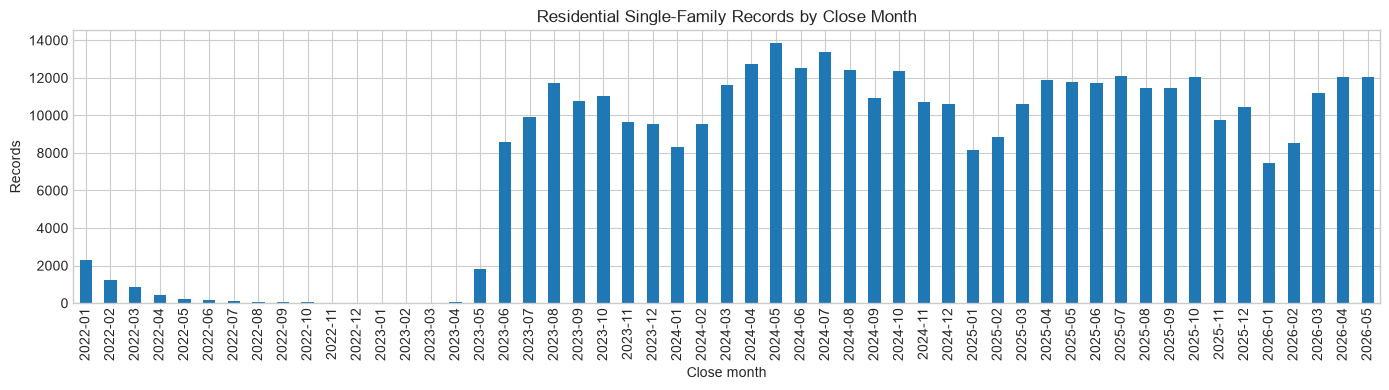

In [12]:
eda.assign(close_month=eda["CloseDate"].dt.to_period("M")).groupby("close_month").size().plot(
    kind="bar",
    figsize=(14, 4),
    title="Residential Single-Family Records by Close Month",
)
plt.xlabel("Close month")
plt.ylabel("Records")
plt.tight_layout()

## Distribution plots

The first set of plots uses all positive, non-missing values. The second set trims to the 1st through 99th percentile so the main distributions are easier to see when there are extreme values.

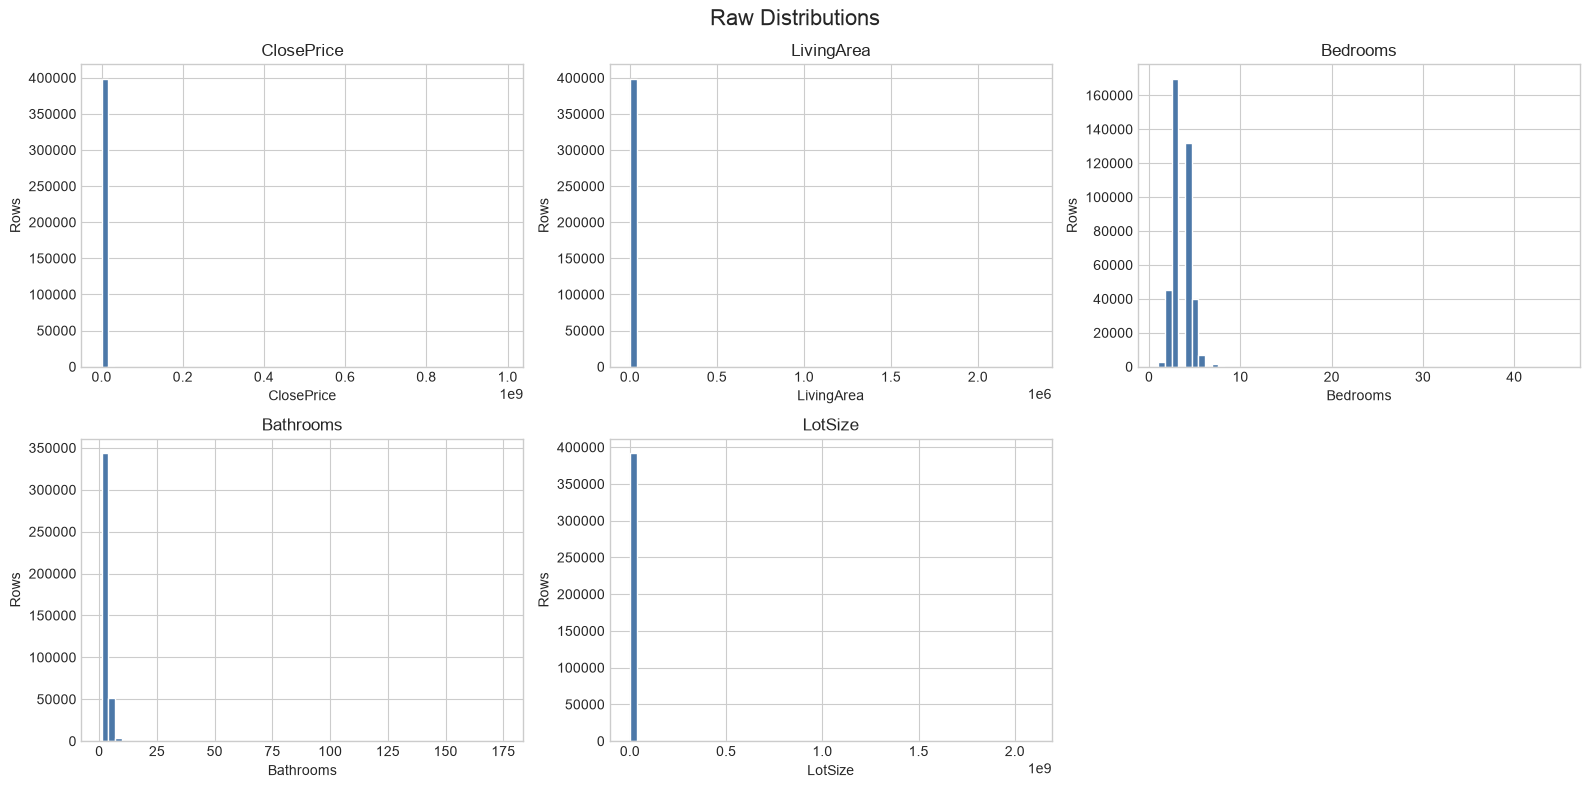

In [13]:
def plot_histograms(data, columns, title, bins=60):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for ax, column in zip(axes, columns):
        values = data[column].dropna()
        values = values[values > 0]
        ax.hist(values, bins=bins, color="#4C78A8", edgecolor="white")
        ax.set_title(column)
        ax.set_xlabel(column)
        ax.set_ylabel("Rows")

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()


plot_histograms(eda, eda_fields, "Raw Distributions")

In [14]:
trimmed = eda.copy()

for column in eda_fields:
    positive = trimmed.loc[trimmed[column] > 0, column]
    lower, upper = positive.quantile([0.01, 0.99])
    trimmed = trimmed.loc[trimmed[column].isna() | trimmed[column].between(lower, upper)]

len(eda), len(trimmed), len(trimmed) / len(eda)

(399157, 370223, 0.9275122320290011)

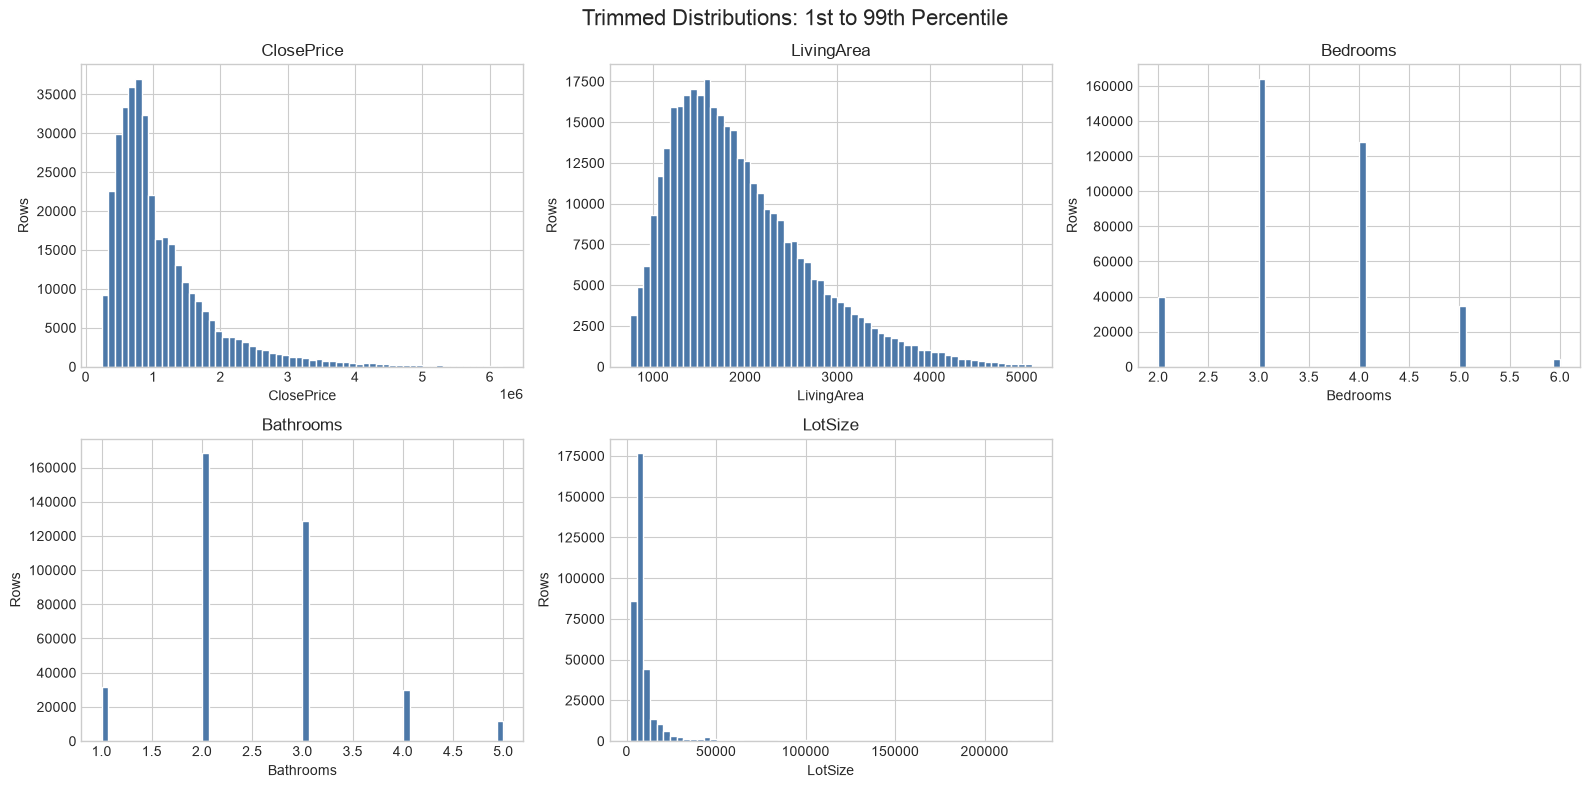

In [15]:
plot_histograms(trimmed, eda_fields, "Trimmed Distributions: 1st to 99th Percentile")

## Box plots

/var/folders/gf/vxk2rst54wlb4z9gnqzsqs7m0000gn/T/ipykernel_55107/614575582.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, showfliers=False)
/var/folders/gf/vxk2rst54wlb4z9gnqzsqs7m0000gn/T/ipykernel_55107/614575582.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, showfliers=False)
/var/folders/gf/vxk2rst54wlb4z9gnqzsqs7m0000gn/T/ipykernel_55107/614575582.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, showfliers=False)
/var/folders/gf/vxk2rst54wlb4z9gnqzsqs7m0000gn/T/ipykernel_55107/614575582.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated

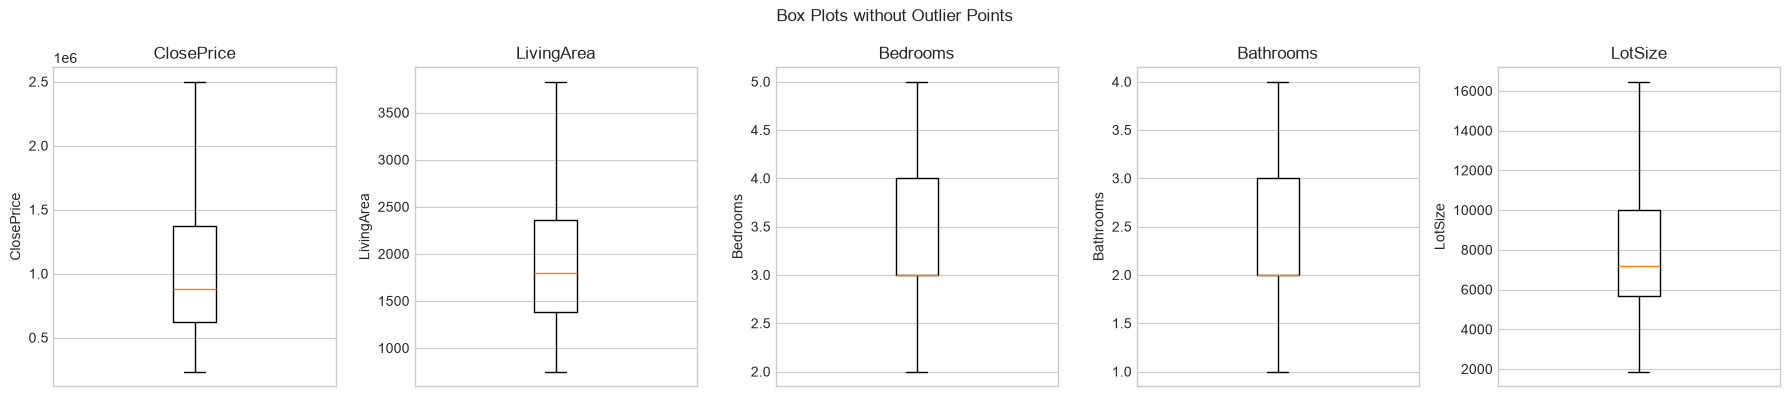

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, column in zip(axes, eda_fields):
    values = trimmed[column].dropna()
    values = values[values > 0]
    ax.boxplot(values, vert=True, showfliers=False)
    ax.set_title(column)
    ax.set_xticks([])
    ax.set_ylabel(column)

fig.suptitle("Box Plots without Outlier Points")
plt.tight_layout()

## Target relationships

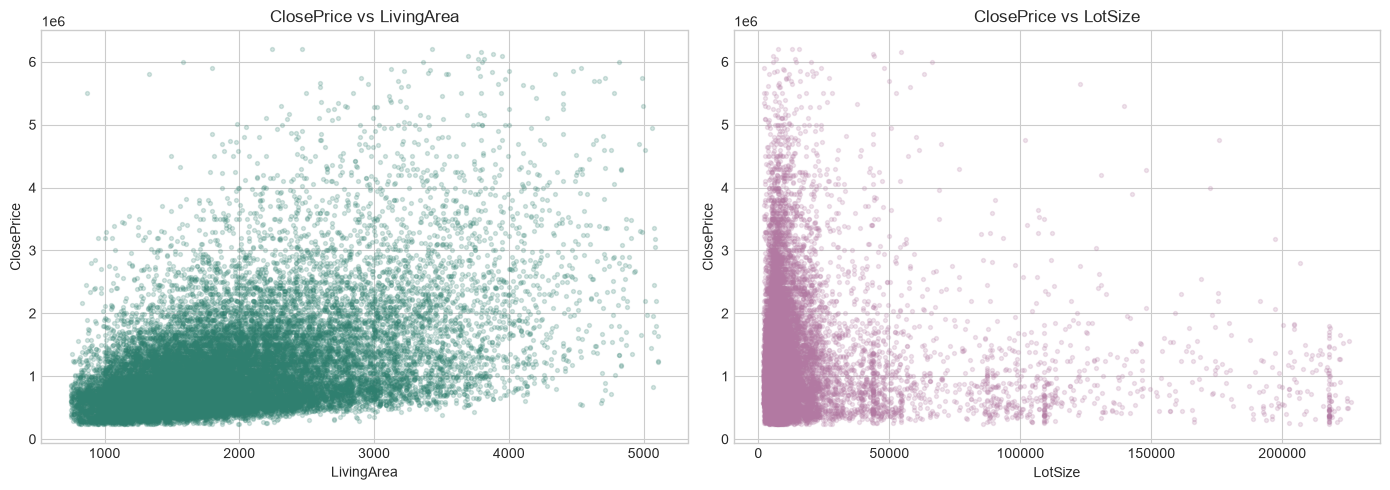

In [17]:
sample = trimmed.dropna(subset=["ClosePrice", "LivingArea", "LotSize"]).sample(
    n=min(25_000, trimmed.dropna(subset=["ClosePrice", "LivingArea", "LotSize"]).shape[0]),
    random_state=50,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample["LivingArea"], sample["ClosePrice"], alpha=0.2, s=8, color="#2F7F6F")
axes[0].set_title("ClosePrice vs LivingArea")
axes[0].set_xlabel("LivingArea")
axes[0].set_ylabel("ClosePrice")

axes[1].scatter(sample["LotSize"], sample["ClosePrice"], alpha=0.2, s=8, color="#B279A2")
axes[1].set_title("ClosePrice vs LotSize")
axes[1].set_xlabel("LotSize")
axes[1].set_ylabel("ClosePrice")

plt.tight_layout()

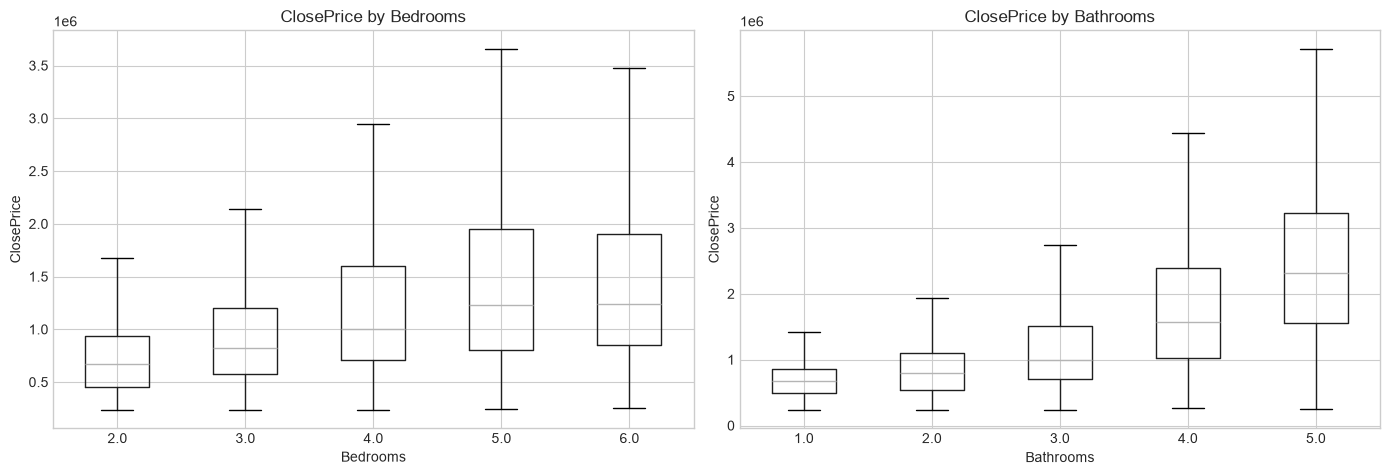

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, column in zip(axes, ["Bedrooms", "Bathrooms"]):
    grouped = trimmed.dropna(subset=[column, "ClosePrice"]).copy()
    grouped = grouped.loc[grouped[column].between(0, 10)]
    grouped.boxplot(column="ClosePrice", by=column, ax=ax, showfliers=False)
    ax.set_title(f"ClosePrice by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("ClosePrice")

plt.suptitle("")
plt.tight_layout()

## Quick notes

- The notebook filters to the exact task scope before plotting.
- `ClosePrice` is treated as the target and is not used as an input feature.
- `LotSizeSquareFeet` is preferred for `LotSize`; `LotSizeArea` is only used as a fallback for missing values.
- Extreme values are not deleted from the source data. The trimmed dataframe is used only to make plots easier to read.